# Dimensional Reduction — GSE225275

**Dataset**: GSE225275 — Gastric antrum across 3 species (human, mouse, rat; 1 sample each)

**Workflow**: Process each species independently (different gene name conventions, no cross-species integration).

Per species:
1. Load QC-filtered data
2. Normalize, log-transform, select HVGs
3. Cell cycle scoring with partial regression
4. PCA -> neighbors -> UMAP -> preliminary clustering

**No Harmony integration** — 1 sample per species, no batch effects to correct.

| Species | Cells | Genes | percent_mito | Regression |
|---------|-------|-------|-------------|------------|
| Human | 3,761 | 12,407 | 0.00-1.04% | cc_difference + percent_mito |
| Mouse | 3,897 | 11,361 | 0.00-0.29% | cc_difference + percent_mito |
| Rat | 3,427 | 11,174 | all 0.00% | cc_difference only |

**Input**: `GSE225275_{species}_filtered.h5ad`
**Output**: `GSE225275_{species}_dimred.h5ad`

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(6, 6), facecolor='white')
sc.settings.verbosity = 3

## 1. Configuration

In [2]:
import os

DATASET_ID = 'GSE225275'
INPUT_DIR = '../data/processed'
OUTPUT_DIR = '../data/processed'
SPECIES_LIST = ['human', 'mouse', 'rat']

# Species-specific settings
SPECIES_CONFIG = {
    'human': {
        'cc_convert': lambda g: g,             # Human gene names as-is
        'mt_pattern': '^MT-',
        'rb_pattern': '^RP[SL]',
        'hb_pattern': '^HB[^(P)]',
        'regress_mito': True,                  # percent_mito 0.00-1.04%
    },
    'mouse': {
        'cc_convert': lambda g: g.capitalize(), # MCM5 -> Mcm5
        'mt_pattern': '^mt-',
        'rb_pattern': '^Rp[sl]',
        'hb_pattern': '^Hb[^(p)]',
        'regress_mito': True,                  # percent_mito 0.00-0.29%
    },
    'rat': {
        'cc_convert': lambda g: g.capitalize(), # Same as mouse
        'mt_pattern': '^mt-',
        'rb_pattern': '^Rp[sl]',
        'hb_pattern': '^Hb[^(p)]',
        'regress_mito': False,                 # percent_mito all 0.00
    },
}

## 2. Load Data

In [3]:
adatas = {}
for species in SPECIES_LIST:
    path = f'{INPUT_DIR}/{DATASET_ID}_{species}_filtered.h5ad'
    adata = sc.read_h5ad(path)
    adatas[species] = adata
    print(f"{species}: {adata.n_obs} cells x {adata.n_vars} genes")

print(f"\nTotal cells: {sum(a.n_obs for a in adatas.values())}")

human: 3761 cells x 12407 genes
mouse: 3897 cells x 11361 genes
rat: 3427 cells x 11174 genes

Total cells: 11085


## 3. Define Cell Cycle Gene Lists

In [4]:
# Tirosh et al. 2016 cell cycle genes (human names)
s_genes_human = ['MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2',
    'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP', 'HELLS', 'RFC2', 'RPA2',
    'NASP', 'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2',
    'ATAD2', 'RAD51', 'RRM2', 'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM',
    'CASP8AP2', 'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8']

g2m_genes_human = ['HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80',
    'CKS2', 'NUF2', 'CKS1B', 'MKI67', 'TMPO', 'CENPF', 'TACC3', 'FAM64A', 'SMC4',
    'CCNB2', 'CKAP2L', 'CKAP2', 'AURKB', 'BUB1', 'KIF11', 'ANP32E', 'TUBB4B',
    'GTSE1', 'KIF20B', 'HJURP', 'CDCA3', 'HN1', 'CDC20', 'TTK', 'CDC25C', 'KIF2C',
    'RANGAP1', 'NCAPD2', 'DLGAP5', 'CDCA2', 'CDCA8', 'ECT2', 'KIF23', 'HMMR',
    'AURKA', 'PSRC1', 'ANLN', 'LBR', 'CKAP5', 'CENPE', 'CTCF', 'NEK2', 'G2E3',
    'GAS2L3', 'CBX5', 'CENPA']

## 4. Process Each Species

Full pipeline per species: normalize -> HVGs -> cell cycle -> regress -> PCA -> UMAP -> cluster.

In [5]:
n_pcs = 40

for species in SPECIES_LIST:
    cfg = SPECIES_CONFIG[species]
    adata = adatas[species]

    print(f"\n{'#' * 70}")
    print(f"# PROCESSING: {species.upper()} ({adata.n_obs} cells x {adata.n_vars} genes)")
    print(f"{'#' * 70}")

    # --- Save raw counts ---
    if 'counts' not in adata.layers:
        adata.layers['counts'] = adata.X.copy()

    # --- Normalize ---
    print("\n--- Normalization ---")
    sc.pp.normalize_total(adata, target_sum=1e4)
    adata.layers['normalized'] = adata.X.copy()
    sc.pp.log1p(adata)
    adata.layers['log1p'] = adata.X.copy()
    print(f"  .X range: {adata.X.min():.2f} to {adata.X.max():.2f}")

    # --- HVG selection (no batch_key — single sample) ---
    print("\n--- HVG Selection ---")
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    mt_genes = adata.var_names.str.match(cfg['mt_pattern'])
    rb_genes = adata.var_names.str.match(cfg['rb_pattern'])
    hb_genes = adata.var_names.str.match(cfg['hb_pattern'])

    exclude_mask = mt_genes | rb_genes | hb_genes
    n_excluded = (exclude_mask & adata.var['highly_variable']).sum()
    adata.var.loc[exclude_mask, 'highly_variable'] = False
    print(f"  HVGs: {adata.var['highly_variable'].sum()} (excluded {n_excluded} mt/ribo/hb)")

    # --- Cell cycle scoring ---
    print("\n--- Cell Cycle Scoring ---")
    s_genes = [cfg['cc_convert'](g) for g in s_genes_human]
    g2m_genes = [cfg['cc_convert'](g) for g in g2m_genes_human]

    s_use = [g for g in s_genes if g in adata.var_names]
    g2m_use = [g for g in g2m_genes if g in adata.var_names]
    print(f"  S genes: {len(s_use)}/{len(s_genes)}, G2M genes: {len(g2m_use)}/{len(g2m_genes)}")

    sc.tl.score_genes_cell_cycle(adata, s_genes=s_use, g2m_genes=g2m_use)
    print(f"  Phase distribution: {adata.obs['phase'].value_counts().to_dict()}")

    # --- Regression ---
    print("\n--- Regression ---")
    adata.obs['cc_difference'] = adata.obs['S_score'] - adata.obs['G2M_score']

    vars_to_regress = ['cc_difference']
    if cfg['regress_mito']:
        vars_to_regress.append('percent_mito')
    print(f"  Regressing: {vars_to_regress}")

    sc.pp.regress_out(adata, keys=vars_to_regress)
    sc.pp.scale(adata, max_value=10)

    # --- PCA ---
    print("\n--- PCA ---")
    sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
    print(f"  Shape: {adata.obsm['X_pca'].shape}")

    # --- Neighbors + UMAP (no integration — single sample) ---
    print("\n--- UMAP ---")
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs, metric='cosine', use_rep='X_pca')
    sc.tl.umap(adata, min_dist=0.3, spread=1.0)

    # --- Clustering ---
    print("\n--- Clustering ---")
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden_prelim')
    print(f"  Found {adata.obs['leiden_prelim'].nunique()} clusters")

    adatas[species] = adata

print("\n" + "=" * 70)
print("All species processed")


######################################################################
# PROCESSING: HUMAN (3761 cells x 12407 genes)
######################################################################

--- Normalization ---
normalizing counts per cell
    finished (0:00:00)
  .X range: 0.00 to 9.01

--- HVG Selection ---
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
  HVGs: 1996 (excluded 4 mt/ribo/hb)

--- Cell Cycle Scoring ---
  S genes: 37/43, G2M genes: 49/54
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    588 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    662 total control genes are used. (0:00:00)
-->     'phase', cell cycle 

/var/folders/m4/5b63q6c147q1q42r6cbt0nsr0000gp/T/ipykernel_34306/4038319077.py:72: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_prelim')


    finished: found 14 clusters and added
    'leiden_prelim', the cluster labels (adata.obs, categorical) (0:00:02)
  Found 14 clusters

######################################################################
# PROCESSING: MOUSE (3897 cells x 11361 genes)
######################################################################

--- Normalization ---
normalizing counts per cell
    finished (0:00:00)
  .X range: 0.00 to 8.79

--- HVG Selection ---
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
  HVGs: 1996 (excluded 4 mt/ribo/hb)

--- Cell Cycle Scoring ---
  S genes: 37/43, G2M genes: 49/54
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    514 total control genes are used. (0:00:00)
computing score 'G2M_score'
    fin

## 5. Cell Cycle Visualization

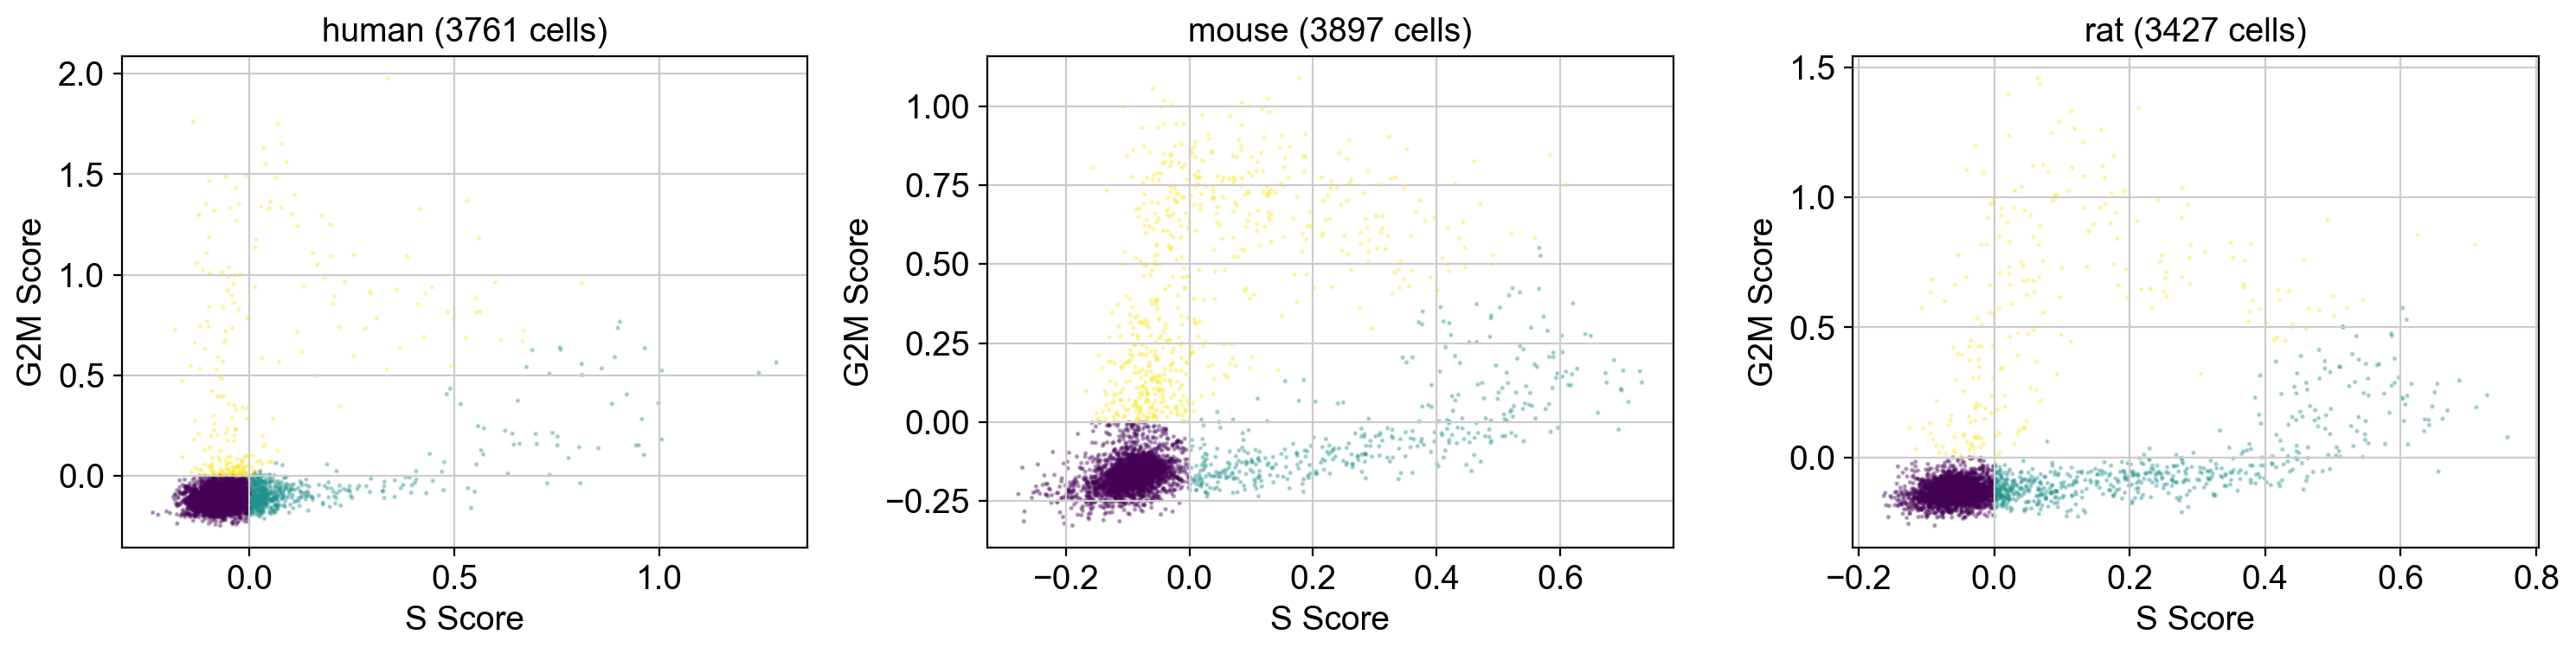

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, species in zip(axes, SPECIES_LIST):
    adata = adatas[species]
    ax.scatter(adata.obs['S_score'], adata.obs['G2M_score'],
               c=adata.obs['phase'].map({'G1': 0, 'S': 1, 'G2M': 2}),
               cmap='viridis', alpha=0.3, s=1)
    ax.set_xlabel('S Score')
    ax.set_ylabel('G2M Score')
    ax.set_title(f'{species} ({adata.n_obs} cells)')

plt.tight_layout()
plt.show()

## 6. PCA Variance

In [7]:
for species in SPECIES_LIST:
    adata = adatas[species]
    variance = np.cumsum(adata.uns['pca']['variance_ratio'])
    n_comp = len(variance)

    pcs_80 = np.where(variance >= 0.80)[0]
    pc_80 = pcs_80[0] + 1 if len(pcs_80) > 0 else f">{n_comp}"

    print(f"{species}: {variance[-1]*100:.1f}% total variance in {n_comp} PCs, 80% at PC {pc_80}")

print(f"\nUsing {n_pcs} PCs for all species")

human: 29.0% total variance in 50 PCs, 80% at PC >50
mouse: 42.4% total variance in 50 PCs, 80% at PC >50
rat: 36.9% total variance in 50 PCs, 80% at PC >50

Using 40 PCs for all species


## 7. UMAP Visualization


UMAP: human


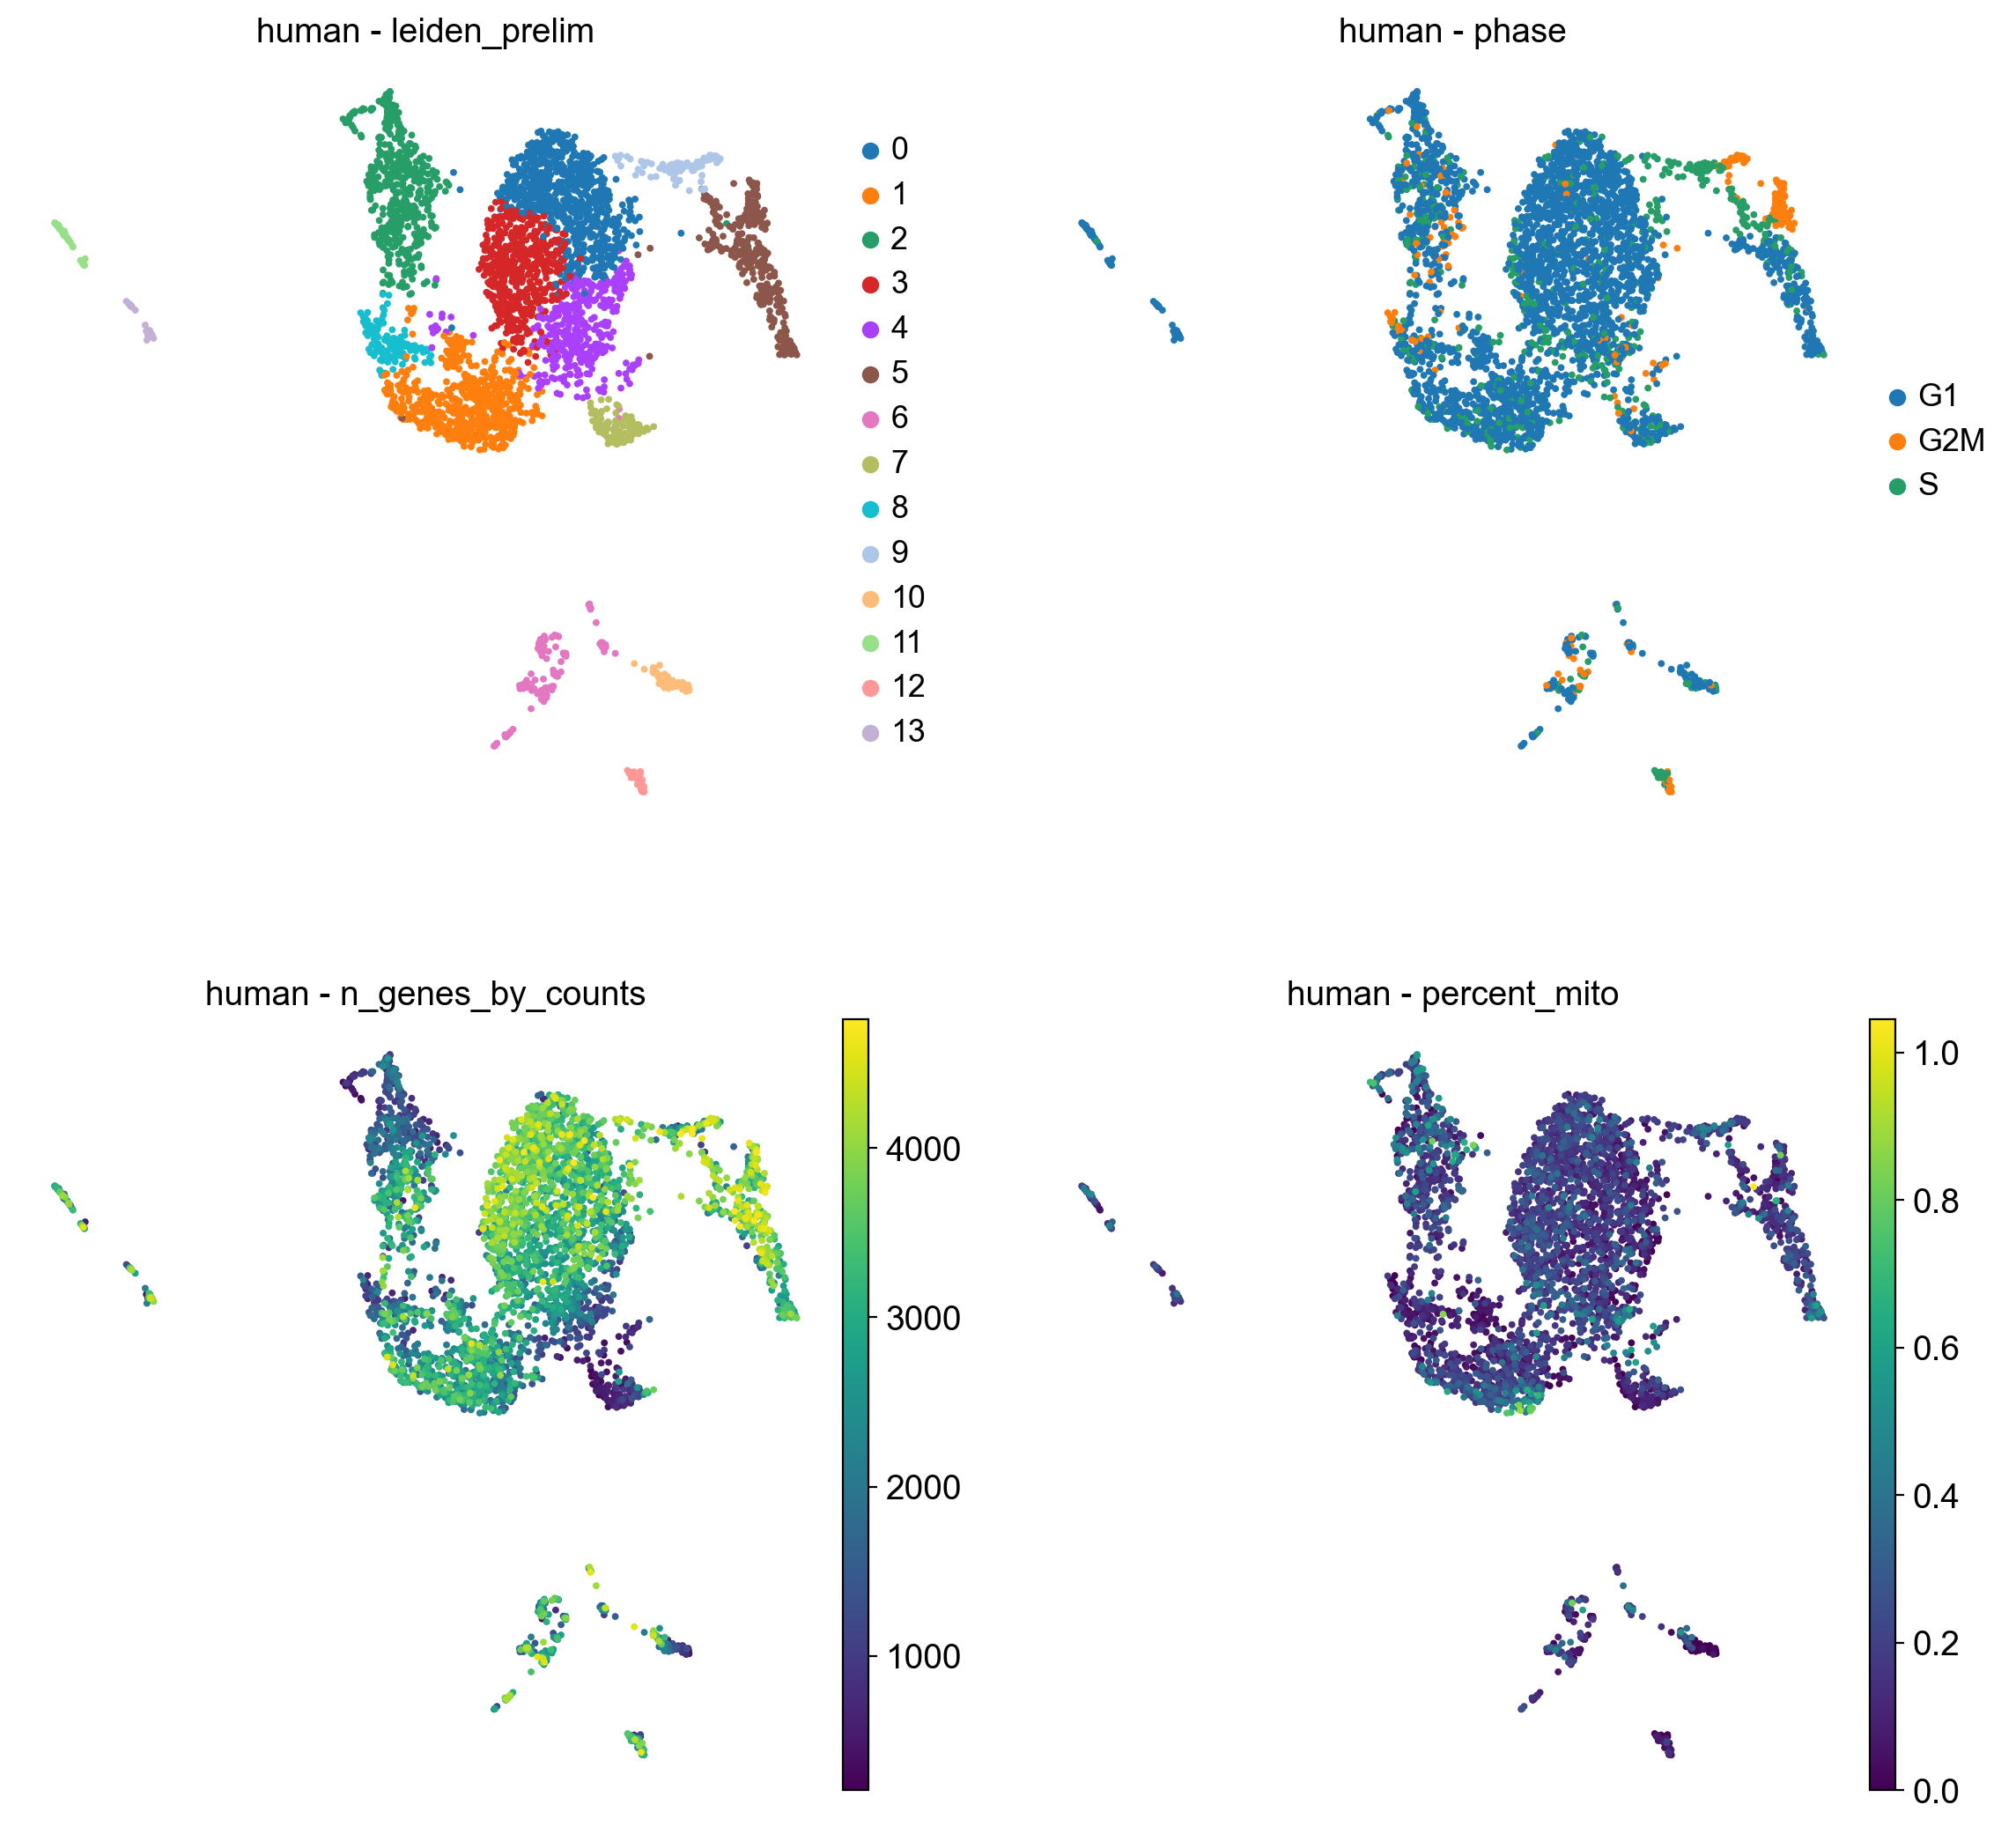


UMAP: mouse


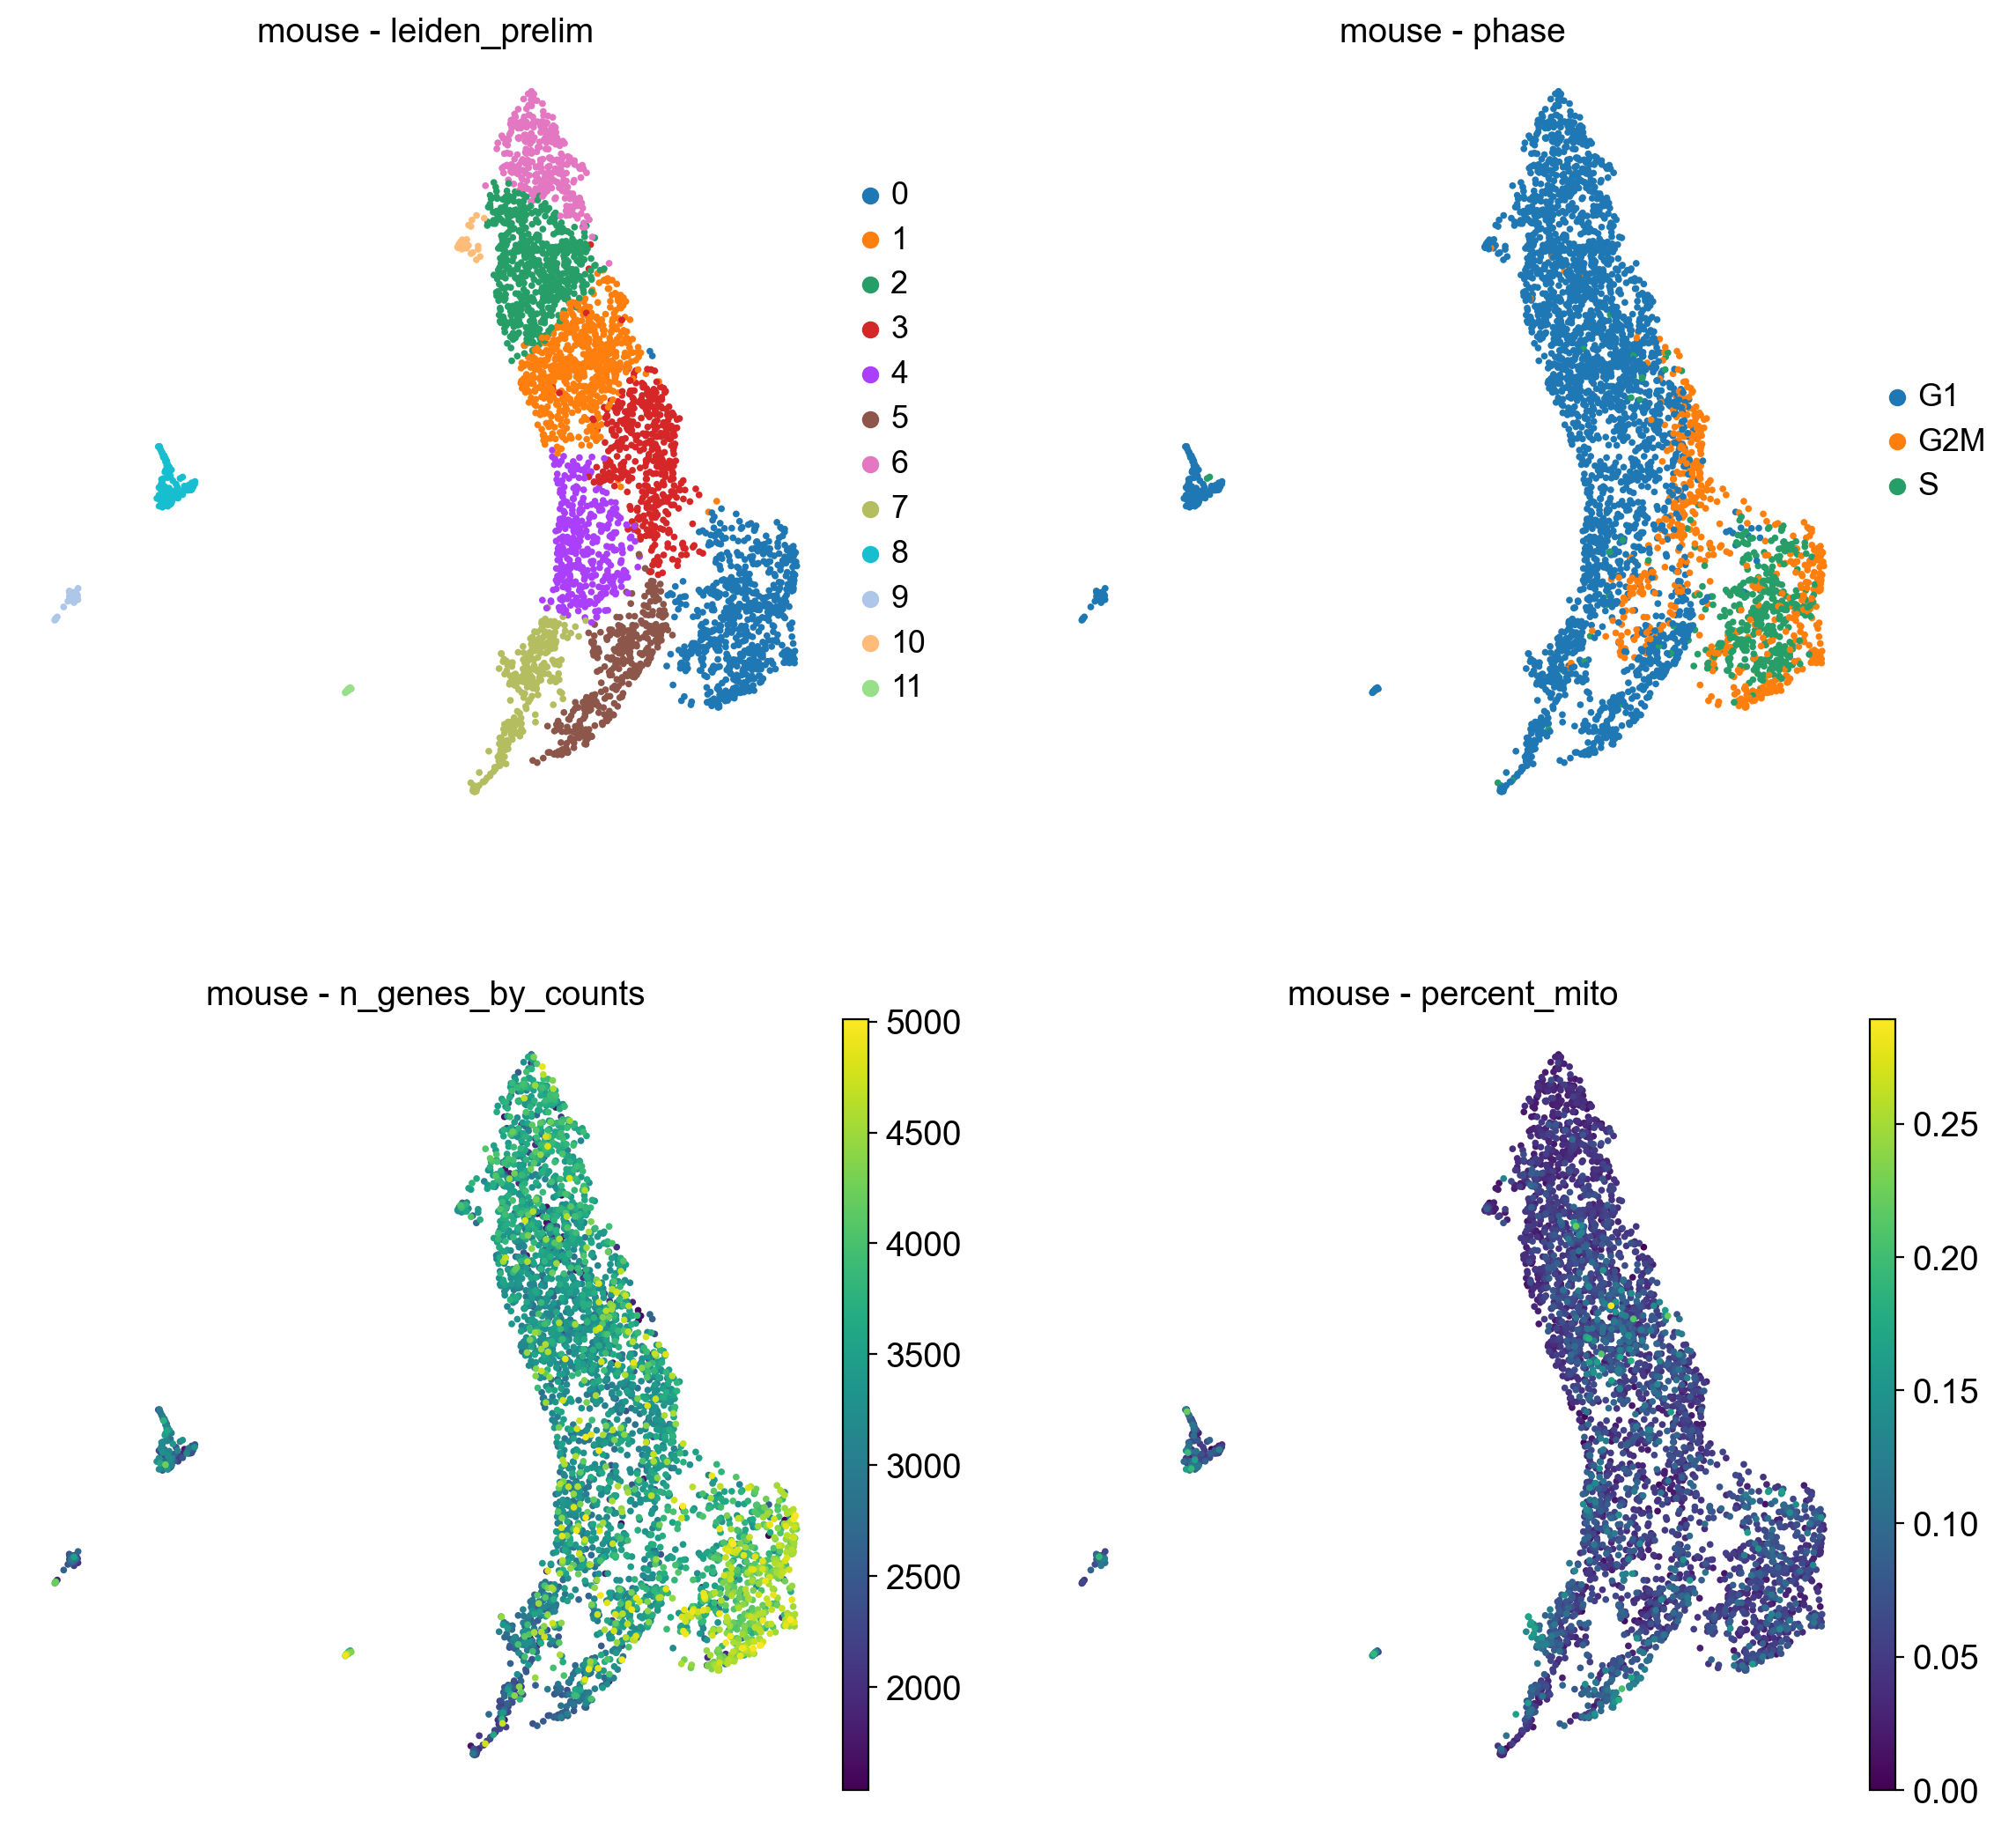


UMAP: rat


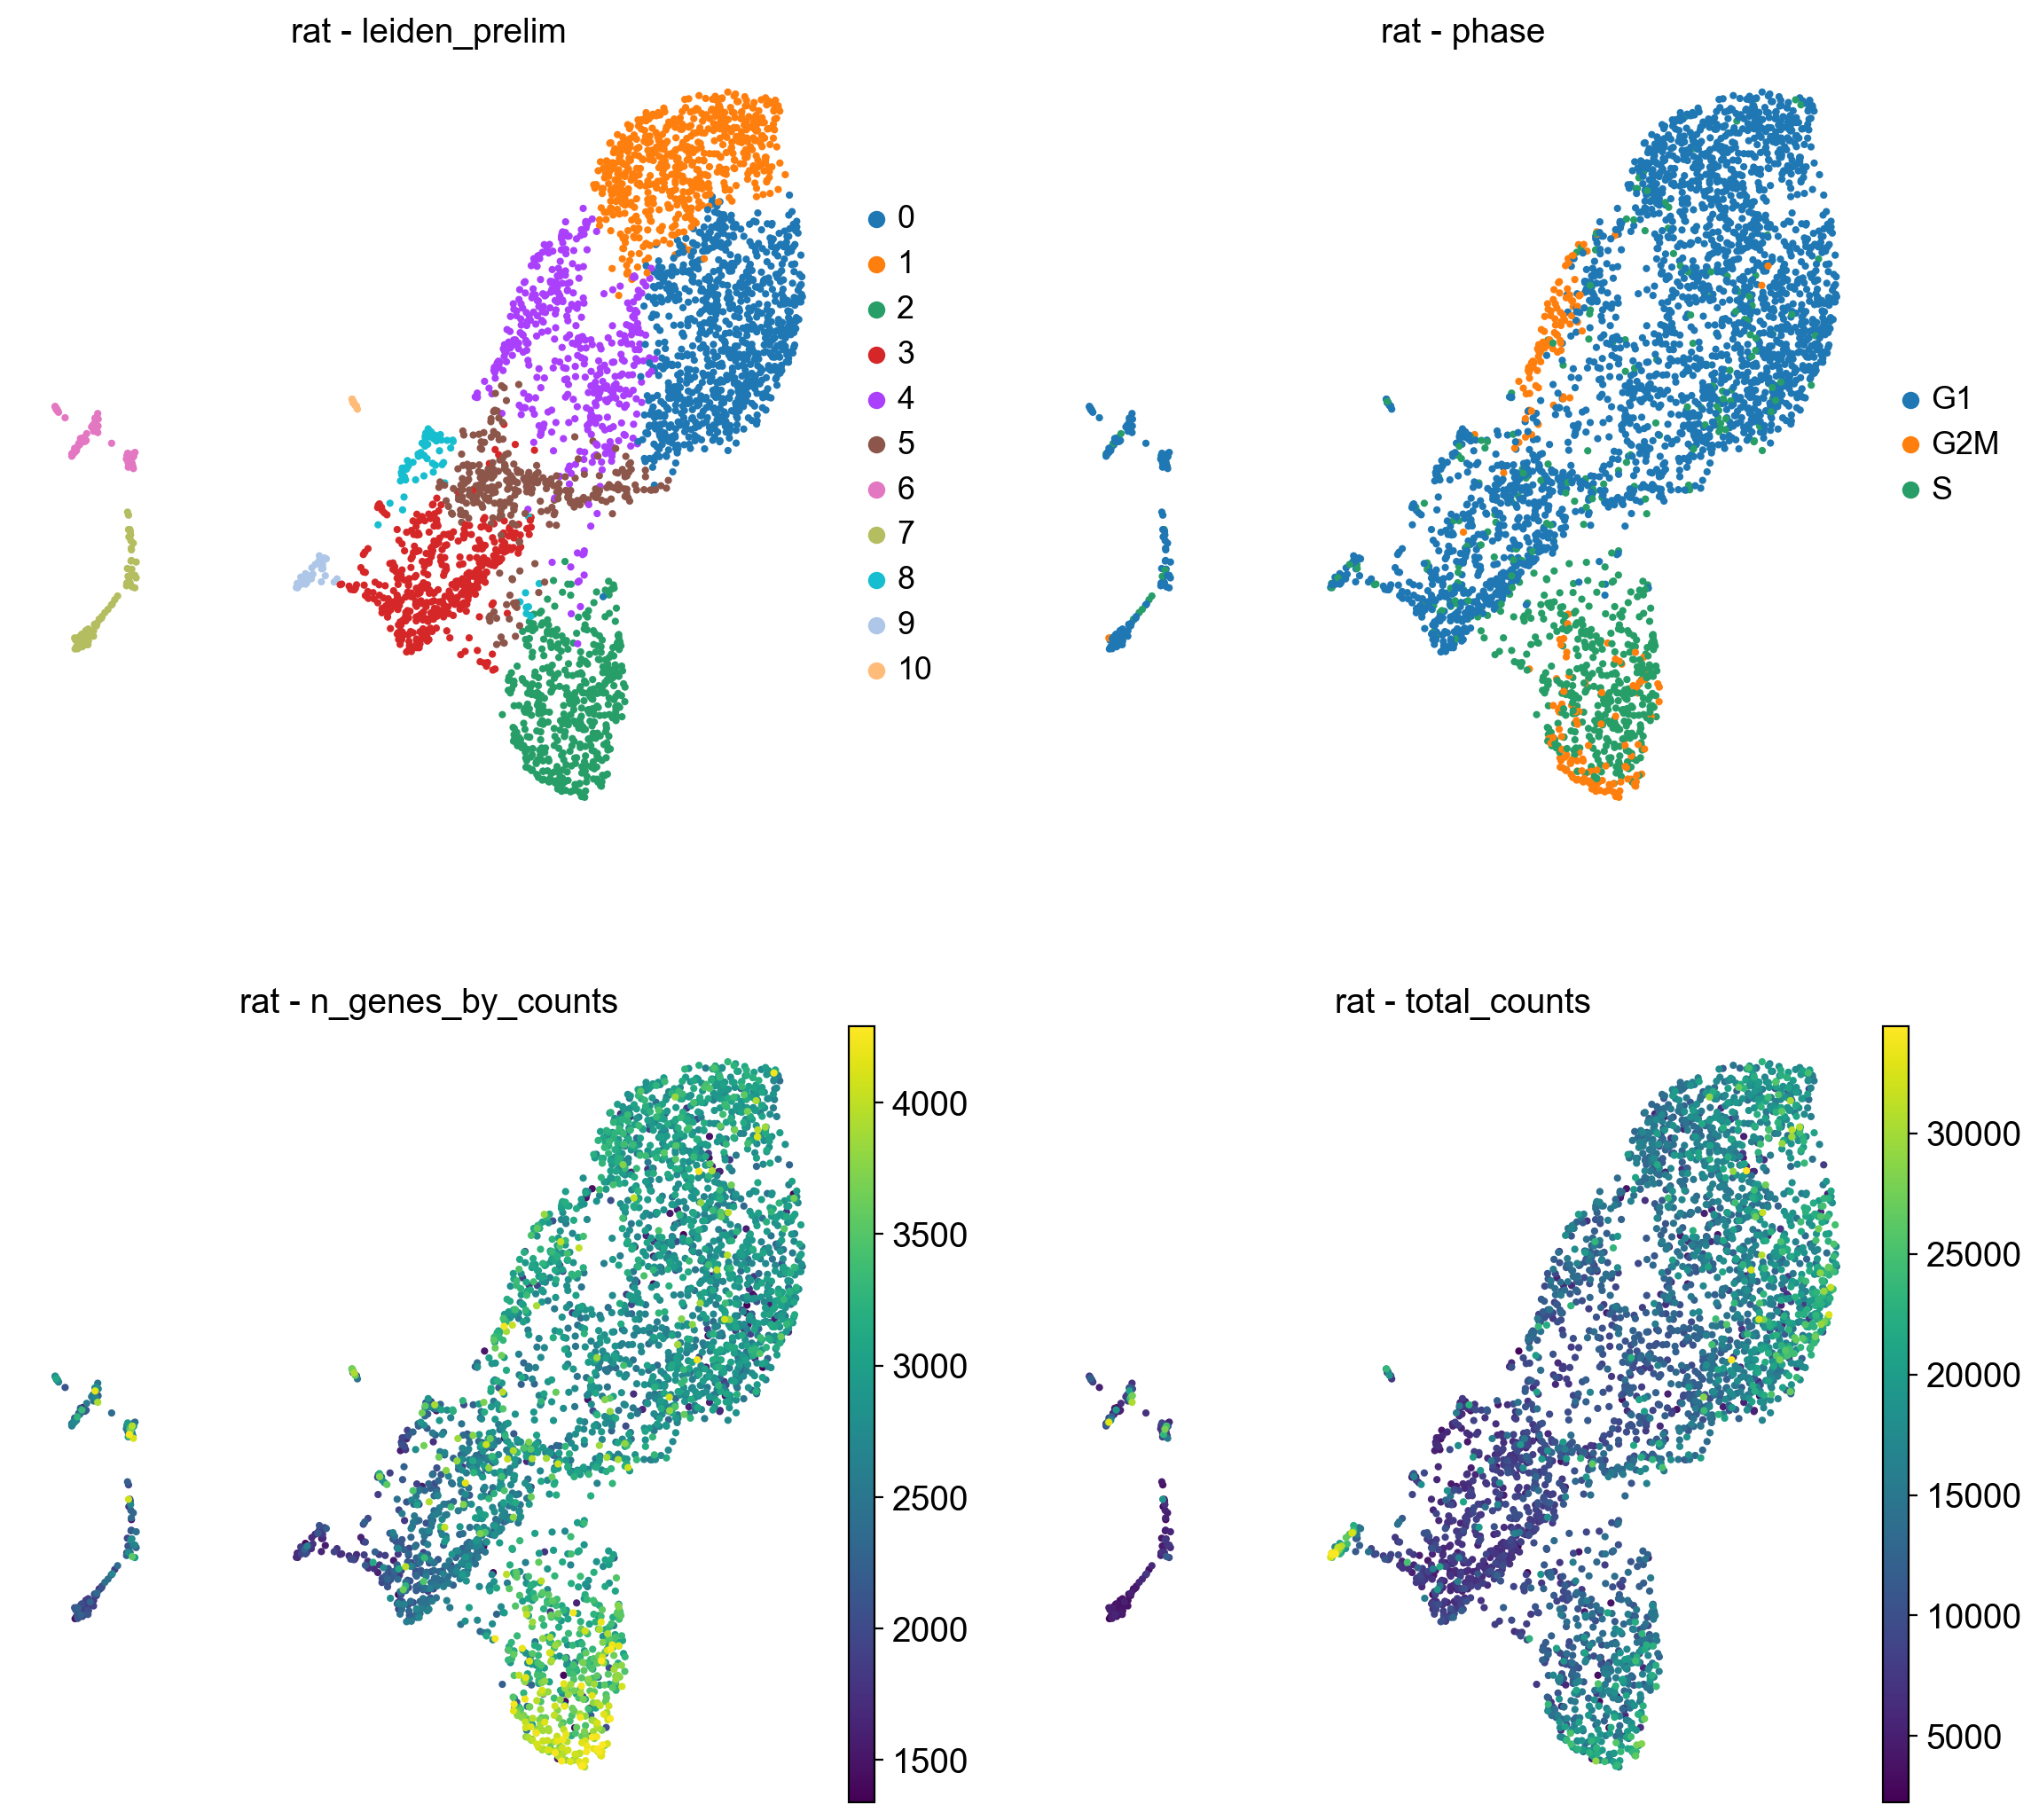

In [8]:
for species in SPECIES_LIST:
    adata = adatas[species]
    cfg = SPECIES_CONFIG[species]

    print(f"\n{'=' * 40}")
    print(f"UMAP: {species}")
    print(f"{'=' * 40}")

    # Choose QC metric (percent_mito if meaningful, else total_counts)
    umap_colors = ['leiden_prelim', 'phase', 'n_genes_by_counts']
    if cfg['regress_mito']:
        umap_colors.append('percent_mito')
    else:
        umap_colors.append('total_counts')

    sc.pl.umap(
        adata,
        color=umap_colors,
        ncols=2,
        frameon=False,
        title=[f'{species} - {c}' for c in umap_colors]
    )

## 8. Cluster Quality Control

In [9]:
for species in SPECIES_LIST:
    adata = adatas[species]
    cfg = SPECIES_CONFIG[species]

    print(f"\n{'=' * 40}")
    print(f"Cluster QC: {species}")
    print(f"{'=' * 40}")

    agg_dict = {
        'n_genes_by_counts': 'median',
        'total_counts': 'median',
        'S_score': 'mean',
        'G2M_score': 'mean'
    }
    if cfg['regress_mito']:
        agg_dict['percent_mito'] = 'median'

    cluster_qc = adata.obs.groupby('leiden_prelim').agg(agg_dict).round(2)
    cluster_qc['n_cells'] = adata.obs['leiden_prelim'].value_counts()
    print(cluster_qc)


Cluster QC: human
               n_genes_by_counts  total_counts  S_score  G2M_score  \
leiden_prelim                                                        
0                         3336.0        8936.0    -0.07      -0.12   
1                         2624.0        6693.5    -0.05      -0.12   
2                         1761.5        3482.5    -0.05      -0.07   
3                         3236.5        8047.0    -0.06      -0.13   
4                         2127.0        4945.0    -0.05      -0.09   
5                         3482.0       10943.0    -0.02       0.00   
6                         2655.5        7082.0     0.05       0.05   
7                          546.0        3373.5    -0.02      -0.04   
8                         1915.5        5715.0    -0.04      -0.04   
9                         3505.0        9442.0     0.29       0.38   
10                        1347.0        3152.0    -0.03      -0.11   
11                        2448.5        4841.5    -0.11      -0.12   
1

/var/folders/m4/5b63q6c147q1q42r6cbt0nsr0000gp/T/ipykernel_34306/4147860535.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_qc = adata.obs.groupby('leiden_prelim').agg(agg_dict).round(2)
/var/folders/m4/5b63q6c147q1q42r6cbt0nsr0000gp/T/ipykernel_34306/4147860535.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_qc = adata.obs.groupby('leiden_prelim').agg(agg_dict).round(2)
/var/folders/m4/5b63q6c147q1q42r6cbt0nsr0000gp/T/ipykernel_34306/4147860535.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

## 9. Save

In [10]:
for species in SPECIES_LIST:
    adata = adatas[species]

    print(f"\n--- {species} ---")
    print(f"  Cells: {adata.n_obs}, Genes: {adata.n_vars}")
    print(f"  Layers: {list(adata.layers.keys())}")
    print(f"  .obsm: {list(adata.obsm.keys())}")
    print(f"  Clusters: {adata.obs['leiden_prelim'].nunique()}")
    print(f"  Phases: {adata.obs['phase'].value_counts().to_dict()}")


--- human ---
  Cells: 3761, Genes: 12407
  Layers: ['counts', 'normalized', 'log1p']
  .obsm: ['X_pca', 'X_umap']
  Clusters: 14
  Phases: {'G1': 2917, 'S': 587, 'G2M': 257}

--- mouse ---
  Cells: 3897, Genes: 11361
  Layers: ['counts', 'normalized', 'log1p']
  .obsm: ['X_pca', 'X_umap']
  Clusters: 12
  Phases: {'G1': 2913, 'G2M': 593, 'S': 391}

--- rat ---
  Cells: 3427, Genes: 11174
  Layers: ['counts', 'normalized', 'log1p']
  .obsm: ['X_pca', 'X_umap']
  Clusters: 11
  Phases: {'G1': 2585, 'S': 614, 'G2M': 228}


In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

for species in SPECIES_LIST:
    adata = adatas[species]
    output_path = f'{OUTPUT_DIR}/{DATASET_ID}_{species}_dimred.h5ad'
    adata.write_h5ad(output_path)
    print(f"Saved: {output_path}")
    print(f"  {adata.n_obs} cells x {adata.n_vars} genes, {os.path.getsize(output_path)/1e6:.1f} MB")

Saved: ../data/processed/GSE225275_human_dimred.h5ad
  3761 cells x 12407 genes, 741.1 MB
Saved: ../data/processed/GSE225275_mouse_dimred.h5ad
  3897 cells x 11361 genes, 843.2 MB
Saved: ../data/processed/GSE225275_rat_dimred.h5ad
  3427 cells x 11174 genes, 663.1 MB


## Summary

In [12]:
print("=" * 60)
print("DIMENSIONAL REDUCTION — GSE225275")
print("=" * 60)

for species in SPECIES_LIST:
    adata = adatas[species]
    cfg = SPECIES_CONFIG[species]
    regress = 'cc_difference + percent_mito' if cfg['regress_mito'] else 'cc_difference only'

    print(f"\n--- {species} ---")
    print(f"  Cells: {adata.n_obs}, Genes: {adata.n_vars}")
    print(f"  Clusters: {adata.obs['leiden_prelim'].nunique()}")
    print(f"  Regression: {regress}")
    print(f"  Integration: None (single sample)")
    print(f"  Output: {OUTPUT_DIR}/{DATASET_ID}_{species}_dimred.h5ad")

total = sum(a.n_obs for a in adatas.values())
print(f"\nTotal cells across species: {total}")

DIMENSIONAL REDUCTION — GSE225275

--- human ---
  Cells: 3761, Genes: 12407
  Clusters: 14
  Regression: cc_difference + percent_mito
  Integration: None (single sample)
  Output: ../data/processed/GSE225275_human_dimred.h5ad

--- mouse ---
  Cells: 3897, Genes: 11361
  Clusters: 12
  Regression: cc_difference + percent_mito
  Integration: None (single sample)
  Output: ../data/processed/GSE225275_mouse_dimred.h5ad

--- rat ---
  Cells: 3427, Genes: 11174
  Clusters: 11
  Regression: cc_difference only
  Integration: None (single sample)
  Output: ../data/processed/GSE225275_rat_dimred.h5ad

Total cells across species: 11085
